*torchvision* - base domain library for computer vision

*torchvision.datasets* - cv datasets 

*torchvision.transforms* - functions for manipulating vision data

*torch.utils.data.Dataset* - Base dataset class for pytroch models

*torch.utils.data.Dataloader* - Creats a python iterable over a dataset

In [1]:

#Importing required libraries
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor 
import pandas as pd

import matplotlib.pyplot as plt
#checking versions
print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


## 1.Getting a dataset    

used dataset : FashoinMNIST.

where to find datasets? 

https://www.image-net.org/

https://docs.pytorch.org/vision/stable/datasets.html

used dataset reference link  : https://github.com/zalandoresearch/fashion-mnist



In [2]:
#setting up training data
train_data = datasets.FashionMNIST(
    root= "data", #Where to download data to ?
    train= True, #Do we want the training dataset
    download = True, # Do we want to download the dataset
    transform= ToTensor(), #Transform the images into tensors
    target_transform= None # Do we want to transform the labels 


)

test_data = datasets.FashionMNIST(
    root = "data" ,
    train = False , #testing dataset
    download=True,
    transform= ToTensor(),
    target_transform = None

)

In [3]:
len(train_data) , len(test_data)
#print(f"Test data dim {test_data.shape()}, Train data dim {train_data.shape()}"


(60000, 10000)

In [4]:
image , label =  train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

*.To tensor()* - converts any image into into the shape (C x H x W) 

C= color channel

H = Height

W = Width

assume the image is only 1 row 

for grayscale - 1*1 matrix ranging from 0 to 1

for rgb - 1*3 matrix ranging from 0 to 1 for each red green and blue value

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
train_data.class_to_idx #shows what label corresponds to which index

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
train_data.targets # shows which tensor corresponds to which label

tensor([9, 0, 0,  ..., 3, 0, 5])

In [8]:
#check the shape of our image
print(f"Image shape : {image.shape} [color channel,heigth,width]")
print(f"label : {class_names[label]}")

Image shape : torch.Size([1, 28, 28]) [color channel,heigth,width]
label : Ankle boot


### 1.2 Visulazing our data

Image shape: torch.Size([1, 28, 28])


TypeError: Invalid shape (1, 28, 28) for image data

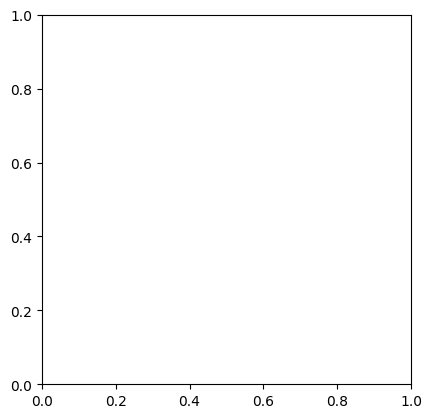

In [9]:
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image)


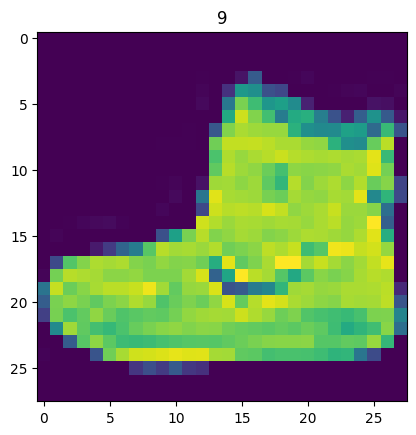

In [10]:
#we squeeze the image so that it is compatible with matplotlib
plt.imshow(image.squeeze())
plt.title(label);

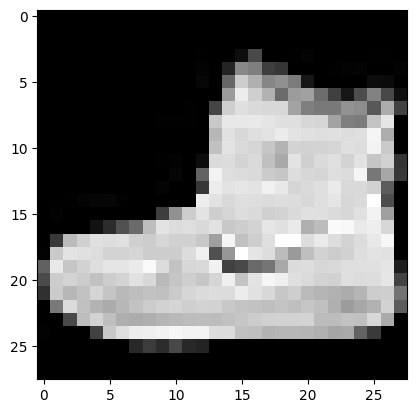

In [11]:
plt.imshow(image.squeeze(),cmap='gray')

37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


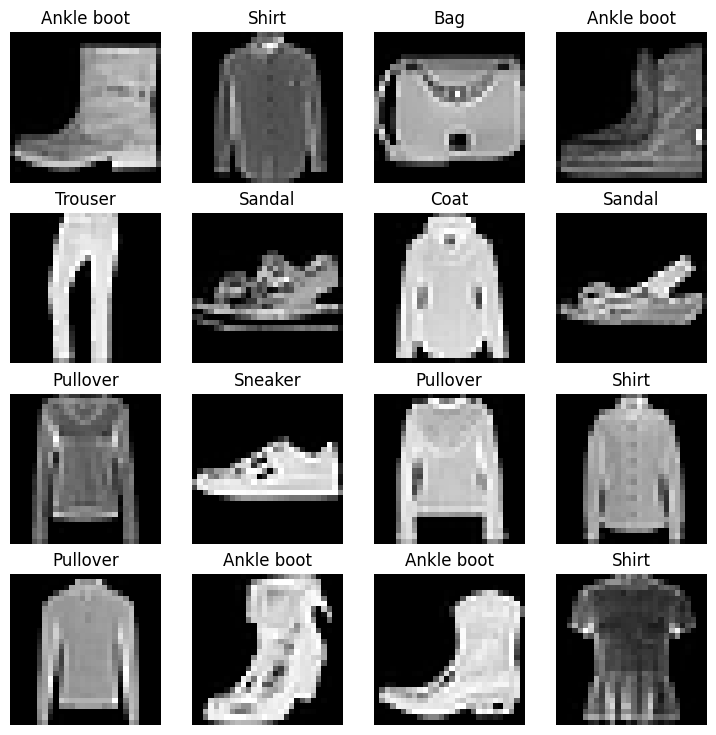

In [17]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,(rows*cols+1)):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    print(random_idx)
    img,label = train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

## 2.Prepare dataloader
Right now, our data is in the form of Pytorch datasets

Dataloader turns our dataset into a python iterable.

More specifically we want to turn our data into batches(or mini-batches)

Why whould we do this:

1.More computationally effecient we cannot put the whole dataset into the ram in one go That's why we split the dataset into batches or mini batches with 32 being the most common batch size

2.It gives our neural network to update its gradients per epoch.
